Total baris data dibaca: 2507
Jumlah data training Linear Regression: 2001
Jumlah data testing Linear Regression : 501

>>> Model Linear Regression dan Scaler Berhasil Disimpan di 'model/'! <<<

     HASIL EVALUASI MODEL LINEAR REGRESSION
Mean Absolute Error (MAE)  : Rp 45.95
Root Mean Squared Error (RMSE): Rp 60.80
R-Squared (R2 Score)       : 98.64%

Sampel Hasil Prediksi Data Uji (10 Baris Pertama):
 Kurs Aktual (Rupiah)  Prediksi LR (Rupiah)  Selisih (Error)
              15189.0          15340.933471       151.933471
              15174.0          15160.390996        13.609004
              15088.0          15159.006460        71.006460
              15094.0          15066.546873        27.453127
              15062.0          15082.388108        20.388108
              14977.0          15051.454950        74.454950
              14990.0          14958.474946        31.525054
              14913.0          14983.308535        70.308535
              14933.0          14896.933050  

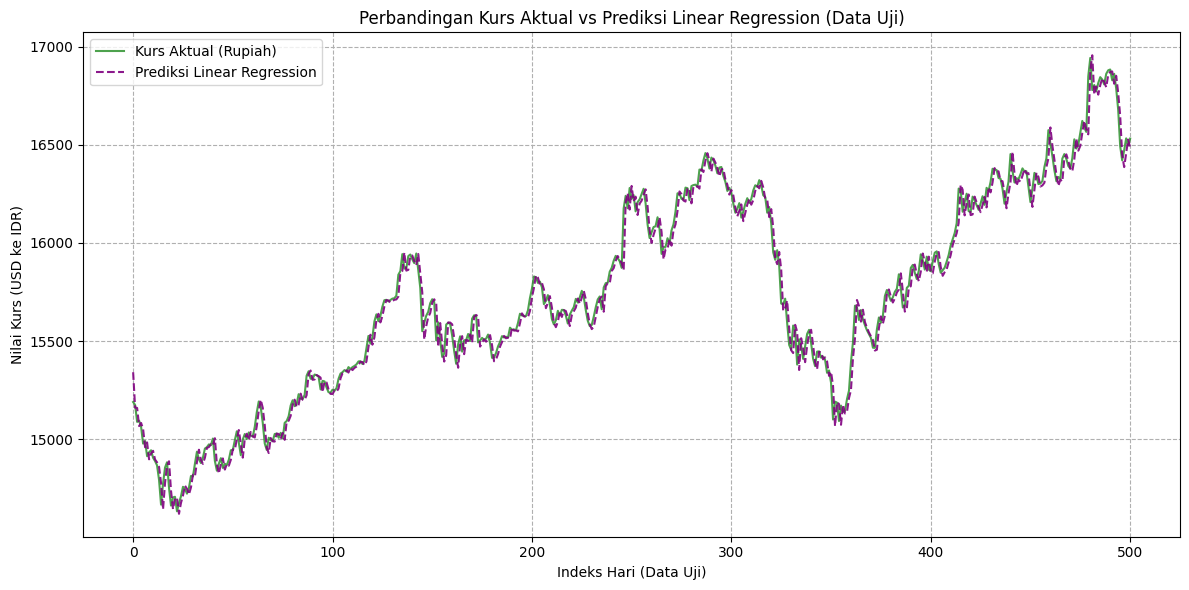

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================================================
# 1. LOAD DAN PREPROCESSING DATA (Sifat Time Series Windowing)
# =====================================================================
# Membaca data CSV dari folder data (keluar dari folder notebook)
df = pd.read_csv('../data/USD-IDR.csv', sep=';')
df = df.dropna(subset=['Kurs'])
df = df.iloc[::-1].reset_index(drop=True) # Urutan kronologis (2015-2025)
df['Kurs'] = pd.to_numeric(df['Kurs'])

data_kurs = df['Kurs'].values.reshape(-1, 1)

# Normalisasi data menggunakan StandardScaler agar adil dengan model Backprop
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_kurs)

# Membuat windowing dataset (5 hari sebelumnya menjadi fitur X, hari ke-6 menjadi target Y)
def create_windowed_dataset(data, window_size=5):
    X, Y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        Y.append(data[i + window_size, 0])
    return np.array(X), np.array(Y)

WINDOW_SIZE = 5
X, Y = create_windowed_dataset(data_scaled, WINDOW_SIZE)

# Memisahkan data secara berurutan/kronologis (80% training, 20% testing)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
Y_train, Y_test = Y[:split_idx], Y[split_idx:]

print(f"Total baris data dibaca: {len(df)}")
print(f"Jumlah data training Linear Regression: {X_train.shape[0]}")
print(f"Jumlah data testing Linear Regression : {X_test.shape[0]}")

# =====================================================================
# 2. MEMBANGUN DAN MELATIH MODEL LINEAR REGRESSION
# =====================================================================
model_lr = LinearRegression()
model_lr.fit(X_train, Y_train)

# =====================================================================
# 2.5. PROSES MENYIMPAN MODEL & SCALER (MENGGUNAKAN JOBLIB)
# =====================================================================
folder_model = '../model'
if not os.path.exists(folder_model):
    os.makedirs(folder_model)

# Menyimpan model Linear Regression dan Scaler-nya
joblib.dump(model_lr, os.path.join(folder_model, 'model_lr_kurs.joblib'))
joblib.dump(scaler, os.path.join(folder_model, 'scaler_lr.joblib'))
print("\n>>> Model Linear Regression dan Scaler Berhasil Disimpan di 'model/'! <<<")

# =====================================================================
# 3. PREDIKSI DAN EVALUASI MODEL (MAE, RMSE, R2)
# =====================================================================
# Prediksi data uji
Y_pred_scaled = model_lr.predict(X_test)

# Denormalisasi (Kembalikan skala ke nilai Rupiah asli)
Y_test_actual = scaler.inverse_transform(Y_test.reshape(-1, 1))
Y_pred_actual = scaler.inverse_transform(Y_pred_scaled.reshape(-1, 1))

# Perhitungan Metrik Evaluasi sesuai Permintaan Anda
mae = mean_absolute_error(Y_test_actual, Y_pred_actual)
rmse = np.sqrt(mean_squared_error(Y_test_actual, Y_pred_actual)) # Mengubah MSE ke RMSE
r2 = r2_score(Y_test_actual, Y_pred_actual)

print("\n" + "="*45)
print("     HASIL EVALUASI MODEL LINEAR REGRESSION")
print("="*45)
print(f"Mean Absolute Error (MAE)  : Rp {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): Rp {rmse:.2f}")
print(f"R-Squared (R2 Score)       : {r2 * 100:.2f}%")
print("="*45)

# =====================================================================
# 4. MENAMPILKAN SAMPEL HASIL PREDIKSI (BENTUK TABEL)
# =====================================================================
hasil_prediksi = pd.DataFrame({
    "Kurs Aktual (Rupiah)": Y_test_actual.flatten(),
    "Prediksi LR (Rupiah)": Y_pred_actual.flatten(),
    "Selisih (Error)": np.abs(Y_test_actual.flatten() - Y_pred_actual.flatten())
})
print("\nSampel Hasil Prediksi Data Uji (10 Baris Pertama):")
print(hasil_prediksi.head(10).to_string(index=False))

# =====================================================================
# 5. VISUALISASI HASIL UNTUK GRAFIK JURNAL
# =====================================================================
plt.figure(figsize=(12, 6))
plt.plot(Y_test_actual, label='Kurs Aktual (Rupiah)', color='forestgreen', alpha=0.8)
plt.plot(Y_pred_actual, label='Prediksi Linear Regression', color='purple', linestyle='--', alpha=0.9)
plt.title('Perbandingan Kurs Aktual vs Prediksi Linear Regression (Data Uji)')
plt.xlabel('Indeks Hari (Data Uji)')
plt.ylabel('Nilai Kurs (USD ke IDR)')
plt.legend()
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()